   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
🔐 Login Required
Username: mycrew
Password: 1234
✅ Login Successful!

🚀 CHATBOT STARTED

💬 Enter message (Enter = Auto): hi

----------------------------
💬 User: hi
🤖 Bot: Working on it...
⏱ Time: 0.89 sec
📊 Total Chats: 1
💬 Enter message (Enter = Auto): hello

----------------------------
💬 User: hello
🤖 Bot: Hi! How can I help you?
⏱ Time: 1.15 sec
📊 Total Chats: 2
💬 Enter message (Enter = Auto): 

----------------------------
💬 User: urgent issue
🤖 Bot: ⚡ Urgent request detected!
⏱ Time: 2.55 sec
📊 Total Chats: 3
💬 Enter message (Enter = Auto): 

----------------------------
💬 User: need help
🤖 Bot: Sure, tell me your issue.
⏱ Time: 1.12 sec
📊 Total Ch

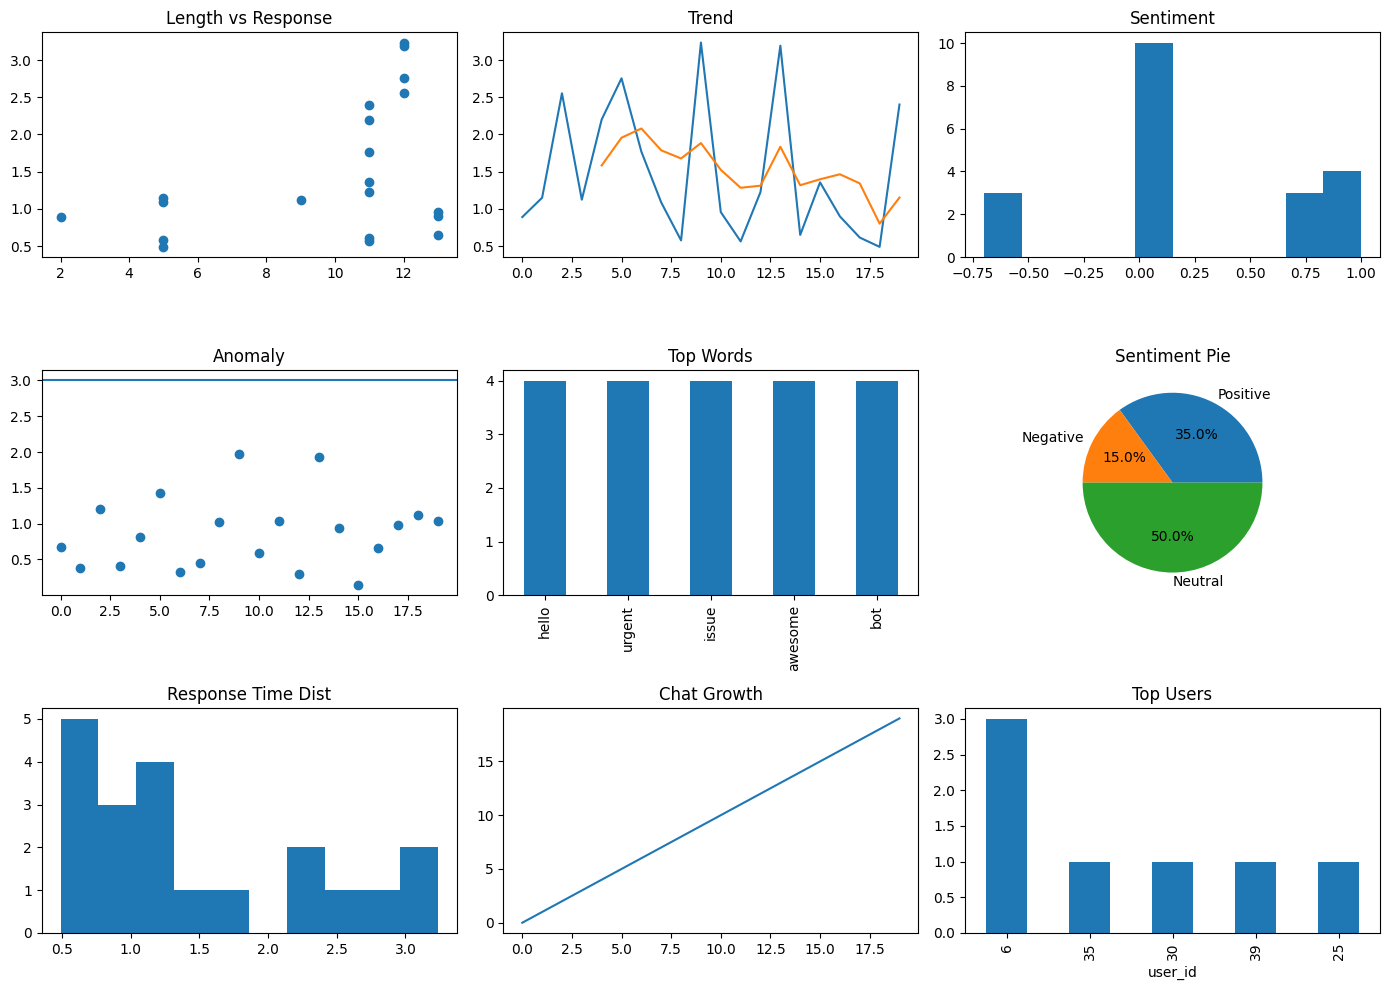

In [ ]:








# =========================
# INSTALL
# =========================
!pip install pandas numpy scikit-learn matplotlib textblob gtts --quiet

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from textblob import TextBlob
from scipy import stats
from gtts import gTTS
from IPython.display import display, Audio, Image

# =========================
# LOGIN
# =========================
print("🔐 Login Required")
if input("Username: ") != "mycrew" or input("Password: ") != "1234":
    print("❌ Access Denied")
    exit()
print("✅ Login Successful!\n")

# =========================
# DATA
# =========================
df = pd.DataFrame(columns=['timestamp','user_id','message_length','response_time','message','response'])

# =========================
# FUNCTIONS
# =========================

def sentiment(text):
    return TextBlob(text).sentiment.polarity

def generate_response(msg):
    msg = msg.lower()
    if "hello" in msg:
        return "Hi! How can I help you?"
    elif "bad" in msg:
        return "Sorry for the inconvenience 😔"
    elif "great" in msg or "awesome" in msg:
        return "Glad you liked it 😊"
    elif "urgent" in msg:
        return "⚡ Urgent request detected!"
    elif "help" in msg:
        return "Sure, tell me your issue."
    else:
        return random.choice(["Processing...", "Got it!", "Working on it..."])

def speak(text):
    try:
        filename = f"voice_{int(time.time())}.mp3"
        tts = gTTS(text)
        tts.save(filename)
        display(Audio(filename, autoplay=True))
    except:
        print("🔇 Voice error")

def dashboard(data):
    plt.figure(figsize=(14,10))

    plt.subplot(3,3,1)
    plt.scatter(data['message_length'], data['response_time'])
    plt.title("Length vs Response")

    plt.subplot(3,3,2)
    data['moving_avg'] = data['response_time'].rolling(5).mean()
    plt.plot(data['response_time'])
    plt.plot(data['moving_avg'])
    plt.title("Trend")

    plt.subplot(3,3,3)
    plt.hist(data['sentiment'])
    plt.title("Sentiment")

    plt.subplot(3,3,4)
    z = np.abs(stats.zscore(data['response_time']))
    plt.scatter(range(len(z)), z)
    plt.axhline(y=3)
    plt.title("Anomaly")

    plt.subplot(3,3,5)
    words = " ".join(data['message']).split()
    pd.Series(words).value_counts().head(5).plot(kind='bar')
    plt.title("Top Words")

    plt.subplot(3,3,6)
    pos = len(data[data['sentiment'] > 0])
    neg = len(data[data['sentiment'] < 0])
    neu = len(data[data['sentiment'] == 0])
    plt.pie([pos, neg, neu], labels=['Positive','Negative','Neutral'], autopct='%1.1f%%')
    plt.title("Sentiment Pie")

    plt.subplot(3,3,7)
    plt.hist(data['response_time'])
    plt.title("Response Time Dist")

    plt.subplot(3,3,8)
    plt.plot(range(len(data)))
    plt.title("Chat Growth")

    plt.subplot(3,3,9)
    data['user_id'].value_counts().head(5).plot(kind='bar')
    plt.title("Top Users")

    plt.tight_layout()
    plt.savefig("final_dashboard.png")
    plt.show()

# =========================
# CHAT SYSTEM
# =========================

messages = ["hello", "bad service", "great support", "urgent issue", "need help", "awesome bot"]

chat_count = 0

print("🚀 CHATBOT STARTED\n")

for i in range(100):

    user_input = input("💬 Enter message (Enter = Auto): ")

    if user_input == "":
        msg = random.choice(messages)
    else:
        msg = user_input

    # BOT RESPONSE
    bot_response = generate_response(msg)

    # RESPONSE TIME
    sent = sentiment(msg)
    if "urgent" in msg:
        response_time = random.uniform(2.5,4)
    elif sent < 0:
        response_time = random.uniform(1.5,3)
    else:
        response_time = random.uniform(0.3,1.5)

    # STORE
    df.loc[len(df)] = [
        time.time(),
        random.randint(1,50),
        len(msg),
        response_time,
        msg,
        bot_response
    ]

    chat_count += 1

    # =========================
    # LIVE DISPLAY (IMPORTANT)
    # =========================
    print("\n----------------------------")
    print(f"💬 User: {msg}")
    print(f"🤖 Bot: {bot_response}")
    print(f"⏱ Time: {round(response_time,2)} sec")
    print(f"📊 Total Chats: {chat_count}")

    # =========================
    # ANALYTICS
    # =========================
    data = df.copy()

    if len(data) > 10:
        data['sentiment'] = data['message'].apply(sentiment)

        X = data[['message_length']]
        y = data['response_time']

        X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

        model = LinearRegression()
        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        mse = mean_squared_error(y_test, pred)

        print(f"📈 MSE: {round(mse,3)}")

    # =========================
    # GRAPH + VOICE हर 20 chats
    # =========================
    if chat_count % 20 == 0 and len(data) > 10:
        print("\n📊 Showing Dashboard...\n")
        dashboard(data)
        speak(f"{chat_count} chats completed. Chatbot analysis done")

    time.sleep(0.5)

# =========================
# FINAL OUTPUT
# =========================

print("\n🔥 FINAL DASHBOARD 🔥")

data = df.copy()
data['sentiment'] = data['message'].apply(sentiment)

dashboard(data)
display(Image("final_dashboard.png"))

speak("Final chatbot analysis completed successfully")

























